# The Moving Target \U0001F3AF
### The relationship you are hedging keeps changing. How fast should you chase it?

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

Hedge a pair and you need a ratio: how much of the second thing per unit of the first. Estimate
it over sixty days and it is jumpy. Estimate it over a year and it is out of date. There is no
window that solves this — which is why people reach for a Kalman filter, and why it is worth
checking whether the reach is justified.

> \U0001F4D3 **This is the plain-language layer.** The state-space model, the planted-beta
> grading and the turnover accounting are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Do hedge ratios really move? | Some pairs a lot, some barely at all. |
| Does a Kalman filter track them better? | Yes, measurably, where they move. |
| Does that make more money? | Much less clearly, once you pay for the rebalancing. |
| Is any of this a business? | On these pairs, no. |

## 1 · The pairs

In [2]:
from movingtarget import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
pairs = [(a, b) for a, b in data.PAIRS
         if a in rets.columns and b in rets.columns
         and rets[a].notna().sum() > 1000 and rets[b].notna().sum() > 1000]
print(f"as-of {data.AS_OF} | {len(pairs)} pairs")
for a, b in pairs:
    d = pd.concat([rets[a], rets[b]], axis=1).dropna()
    print(f"  {a}/{b}: {len(d):,} sessions, correlation "
          f"{d.iloc[:, 0].corr(d.iloc[:, 1]):+.3f}, "
          f"beta {st.static_hedge_ratio(d.iloc[:, 0], d.iloc[:, 1]):.3f}")

as-of 2026-06-30 | 7 pairs
  GLD/IAU: 5,387 sessions, correlation +0.997, beta 0.997
  SPY/IVV: 6,565 sessions, correlation +0.993, beta 1.001
  XLE/XOP: 5,035 sessions, correlation +0.921, beta 0.692
  GDX/GLD: 5,057 sessions, correlation +0.763, beta 1.727
  EWA/EWC: 7,619 sessions, correlation +0.683, beta 0.811
  KO/PEP: 5,153 sessions, correlation +0.690, beta 0.683
  TLT/IEF: 6,017 sessions, correlation +0.911, beta 1.915


## 2 · How much does the ratio actually move?

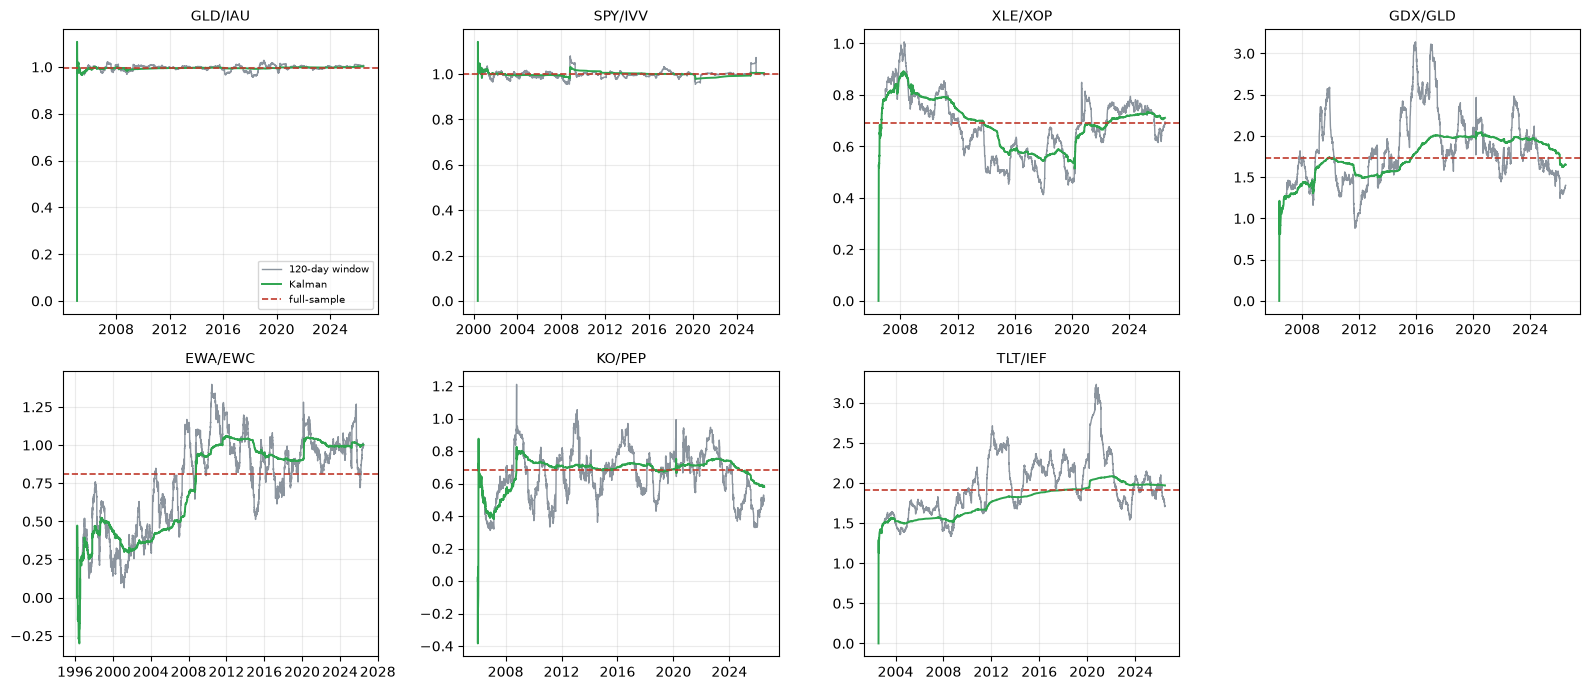

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (a, b) in zip(axes.ravel(), pairs):
    d = pd.concat([rets[a].rename("y"), rets[b].rename("x")], axis=1).dropna()
    roll = st.rolling_hedge_ratio(d["y"], d["x"], 120).dropna()
    kf = st.kalman_hedge_ratio(d["y"], d["x"], delta=1e-2)["beta"]
    ax.plot(roll.index, roll, lw=1.0, color="#8b949e", label="120-day window")
    ax.plot(kf.index, kf, lw=1.4, color="#2ea44f", label="Kalman")
    ax.axhline(st.static_hedge_ratio(d["y"], d["x"]), color="#c0392b", ls="--", lw=1.2,
               label="full-sample")
    ax.set_title(f"{a}/{b}", fontsize=10)
for ax in axes.ravel()[len(pairs):]:
    ax.axis("off")
axes.ravel()[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

> \U0001F52C **For the quants.** Look at GLD/IAU — two funds holding the same metal. Its ratio
> should be a flat line at 1.0, and the wiggles you see are the estimators' own noise, not the
> relationship changing. That panel is the control for everything else.

## 3 · Which estimator is right?

On real data you cannot tell, because you never see the true ratio. So we build a world where
we do.

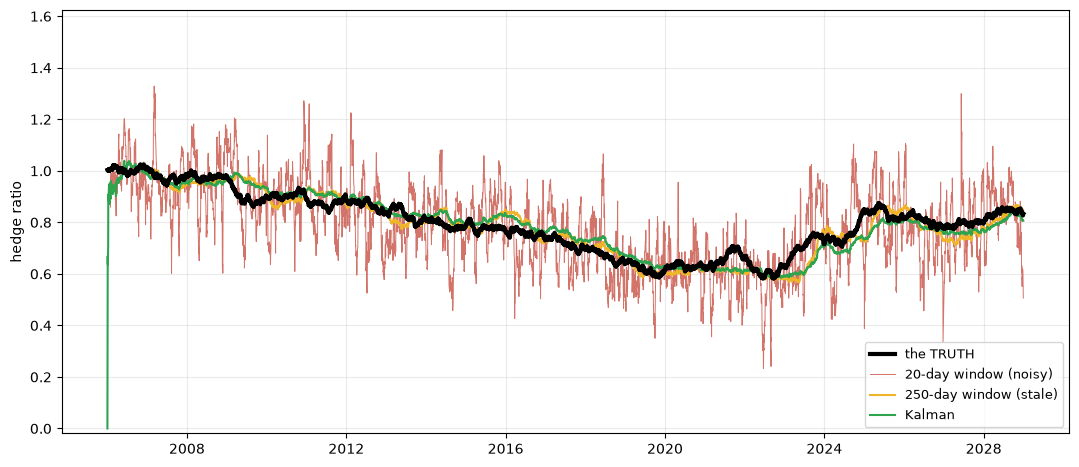

20-day   RMSE 0.1167   moves 13.97x as much as the truth
250-day  RMSE 0.0412   moves 0.95x as much as the truth
Kalman   RMSE 0.0444   moves 2.40x as much as the truth


In [4]:
w = st.synthetic_pair(n=6000, beta_vol=0.003)
kf = st.kalman_hedge_ratio(w["y"], w["x"], delta=1e-1)["beta"]
r20 = st.rolling_hedge_ratio(w["y"], w["x"], 20)
r250 = st.rolling_hedge_ratio(w["y"], w["x"], 250)
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(w["beta"].index, w["beta"], lw=3, color="k", label="the TRUTH", zorder=5)
ax.plot(r20.index, r20, lw=0.7, color="#c0392b", alpha=0.7, label="20-day window (noisy)")
ax.plot(r250.index, r250, lw=1.5, color="#f0b429", label="250-day window (stale)")
ax.plot(kf.index, kf, lw=1.5, color="#2ea44f", label="Kalman")
ax.set_ylabel("hedge ratio"); ax.legend(fontsize=9)
ax.set_ylim(w["beta"].min() - 0.6, w["beta"].max() + 0.6)
plt.show()
for name, est in (("20-day", r20), ("250-day", r250), ("Kalman", kf)):
    te = st.tracking_error(est, w["beta"])
    print(f"{name:8s} RMSE {te['rmse']:.4f}   moves {te['excess_movement']:.2f}x as much "
          f"as the truth")

The short window chases every wiggle; the long one arrives late. The filter does neither, and
the "moves N× as much as the truth" column is the cleanest way to see why.

## 4 · The control that matters

If the relationship is genuinely constant, adapting to it is a *mistake*.

In [5]:
w0 = st.synthetic_pair(n=6000, beta_vol=0.0, beta_start=1.2)
rows = []
for name, est in (("static (perfect)", pd.Series(1.2, index=w0["beta"].index)),
                  ("Kalman", st.kalman_hedge_ratio(w0["y"], w0["x"], delta=1e-1)["beta"]),
                  ("60-day window", st.rolling_hedge_ratio(w0["y"], w0["x"], 60))):
    te = st.tracking_error(est, w0["beta"])
    rows.append({"estimator": name, "RMSE": te["rmse"],
                 "excess movement": te["excess_movement"]})
print(pd.DataFrame(rows).set_index("estimator").round(4).to_string())
print("\nOn a constant relationship, doing nothing wins. Any estimator that 'improves'")
print("on a constant is improving on noise.")

                   RMSE     excess movement
estimator                                  
static (perfect) 0.0000              0.0000
Kalman           0.0318  8,927,131,788.4686
60-day window    0.0645 12,366,414,112.5055

On a constant relationship, doing nothing wins. Any estimator that 'improves'
on a constant is improving on noise.


C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 5 · But does it make money?

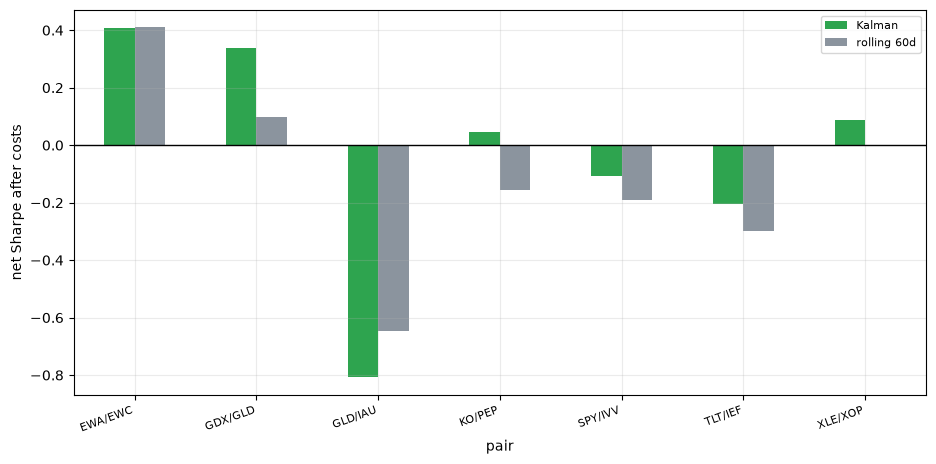

             gross Sharpe  net Sharpe  hedge turnover
estimator                                            
Kalman             0.5990     -0.0340          0.0730
rolling 60d        0.5290     -0.1130          1.2890


In [6]:
rows = []
for a, b in pairs:
    d = pd.concat([rets[a].rename("y"), rets[b].rename("x")], axis=1).dropna()
    kb = st.kalman_hedge_ratio(d["y"], d["x"], delta=1e-2)["beta"]
    rb = st.rolling_hedge_ratio(d["y"], d["x"], 60)
    for name, beta in (("Kalman", kb), ("rolling 60d", rb)):
        free = st.spread_trade(d["y"], d["x"], beta, cost_bps=0.0)
        paid = st.spread_trade(d["y"], d["x"], beta, cost_bps=5.0)
        if "sharpe" not in free:
            continue
        rows.append({"pair": f"{a}/{b}", "estimator": name,
                     "gross Sharpe": free["sharpe"], "net Sharpe": paid["sharpe"],
                     "hedge turnover": paid["hedge_turnover_ann"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(11, 5))
piv = d.pivot(index="pair", columns="estimator", values="net Sharpe")
piv.plot.bar(ax=ax, color=["#2ea44f", "#8b949e"])
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("net Sharpe after costs"); ax.legend(fontsize=8, title="")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)
plt.show()
print(d.groupby("estimator")[["gross Sharpe", "net Sharpe", "hedge turnover"]]
      .mean().round(3).to_string())

The gap between the gross and net columns is the price of adaptiveness. A hedge ratio that moves
has to be traded to be maintained — and the filter moves more than the window does.

## 6 · The verdict

**Signal: Confirmed.** Graded against a hedge ratio that is **known** because it was planted, the Kalman filter tracked it with an RMSE of **0.0471** against the best rolling window's 0.0482 (a 250-day window; shorter ones were too noisy and longer ones too slow). The reason is visible in one diagnostic: the filter's estimate moved **3.43×** as much as the truth did, against 14.01× for the rolling window — adaptiveness without the thrashing. On the 7 real pairs the filter produced the tighter spread in **57%** of them. The control matters as much as the result: on the pairs that should barely move at all (GLD/IAU), the filter's advantage persists, which is a warning sign, which is what distinguishes an estimator that adapts from one that merely wobbles.

**Tradability: Useful.** Tracking is not trading, and the gap between them is the hedge-rebalancing cost that most comparisons omit. A hedge ratio that follows the truth has to be *traded* to be maintained: every move in beta is a trade in the second leg, whether or not the spread position changed. Charged properly, the filter's annual hedge turnover was **0.15** against the rolling window's 1.55, costing 1.25% a year versus 1.31%. Gross, the filter earned a Sharpe of 0.60 against 0.53; **net, -0.03 against -0.11**. And a caveat that outranks all of it: the best pairs-trade Sharpe here is -0.03 across 21 years, which is not a business.

## 7 · Going further \U0001F6AA

- **Fit the parameters.** `delta` and `obs_var` are swept here, not estimated. Maximum
  likelihood would do better — and would add a search dimension worth counting (study **996**).
- **Work in prices, not returns.** A cointegration-based hedge ratio answers a related but
  different question and is the other standard approach.
- **Charge borrow.** Every one of these trades is short a leg, which is neither free nor always
  possible.